
📄 File: Subject00_2.edf
✅ RMSE Reconstruction (25%): 0.9185
✅ RMSE Reconstruction (10%): 0.9901
🧹 RMSE Denoising (G+L): 0.8024


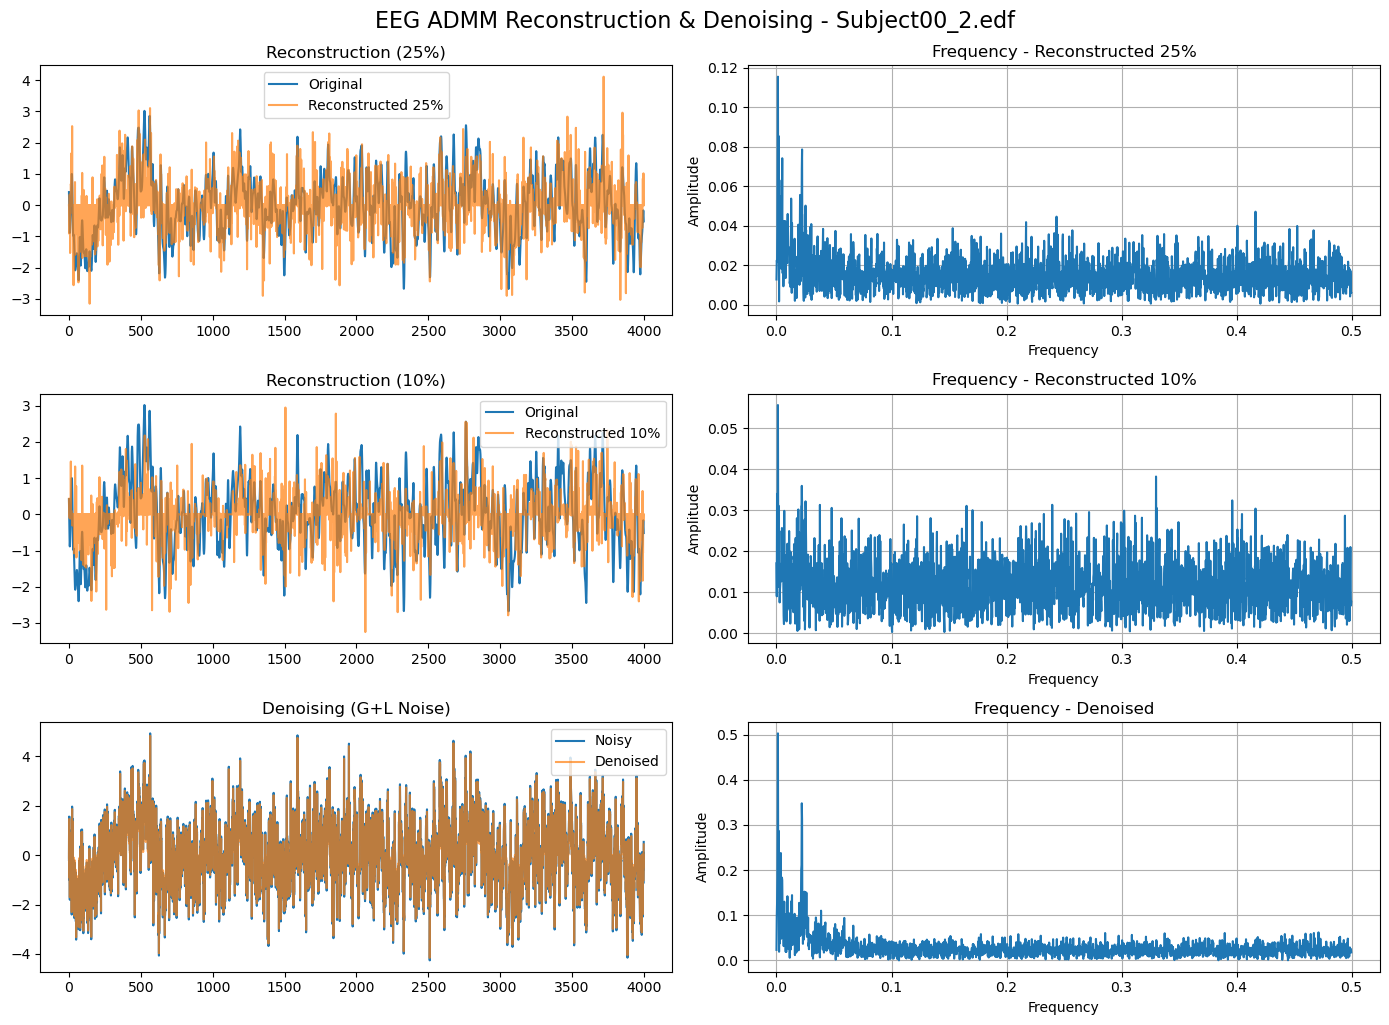

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pyedflib
import os
from scipy.fft import fft, fftfreq

# === Constants ===
DATA_PATH = r'R:\AIE FILES\Semester-3\Projects\MFC3\Paper_1\eeg-during-mental-arithmetic-tasks-1.0.0'
CHANNEL = 0
LAMBDA = 0.1
RHO = 1.0
ITER = 20
MAX_LEN = 4000

# === Soft Thresholding ===
def soft(x, thresh):
    return np.sign(x) * np.maximum(np.abs(x) - thresh, 0)

# === Frequency Plot ===
def plot_frequency(signal, fs=1.0, title="Frequency Response"):
    N = len(signal)
    yf = fft(signal)
    xf = fftfreq(N, 1/fs)[:N//2]
    plt.plot(xf, 2.0/N * np.abs(yf[:N//2]))
    plt.title(title)
    plt.xlabel("Frequency")
    plt.ylabel("Amplitude")
    plt.grid()

# === Load First Subject ===
edf_files = sorted([f for f in os.listdir(DATA_PATH) if f.endswith('_2.edf')])
file = edf_files[0]
path = os.path.join(DATA_PATH, file)
f = pyedflib.EdfReader(path)
signal = f.readSignal(CHANNEL).astype(np.float64)
f.close()

signal = signal[:MAX_LEN]
original = (signal - np.mean(signal)) / np.std(signal)
N = len(original)

# === Step 1: ADMM Reconstruction (25% samples) ===
M_25 = int(0.25 * N)
H_25 = np.random.randn(M_25, N) / np.sqrt(M_25)
y_25 = H_25 @ original

x = np.zeros(N)
z = np.zeros(N)
u = np.zeros(N)
A = H_25.T @ H_25 + RHO * np.eye(N)
for _ in range(ITER):
    b = H_25.T @ y_25 + RHO * (z - u)
    x = np.linalg.solve(A, b)
    z = soft(x + u, LAMBDA / RHO)
    u = u + x - z
rec_25 = z
rmse_25 = np.sqrt(np.mean((original - rec_25) ** 2))

# === Step 2: ADMM Reconstruction (10% samples) ===
M_10 = int(0.10 * N)
H_10 = np.random.randn(M_10, N) / np.sqrt(M_10)
y_10 = H_10 @ original

x = np.zeros(N)
z = np.zeros(N)
u = np.zeros(N)
A = H_10.T @ H_10 + RHO * np.eye(N)
for _ in range(ITER):
    b = H_10.T @ y_10 + RHO * (z - u)
    x = np.linalg.solve(A, b)
    z = soft(x + u, LAMBDA / RHO)
    u = u + x - z
rec_10 = z
rmse_10 = np.sqrt(np.mean((original - rec_10) ** 2))

# === Step 3: Add Gaussian + Laplacian Noise ===
gauss_noise = np.random.normal(0, 0.5, N)
lap_noise = np.random.laplace(0, 0.5, N)
noisy = original + gauss_noise + lap_noise

# === Step 4: ADMM Denoising ===
x = np.zeros(N)
z = np.zeros(N)
u = np.zeros(N)
for _ in range(ITER):
    x = (noisy + RHO * (z - u)) / (1 + RHO)
    z = soft(x + u, LAMBDA / RHO)
    u = u + x - z
denoised = z
rmse_denoise = np.sqrt(np.mean((original - denoised) ** 2))

# === Print Results ===
print(f"\n📄 File: {file}")
print(f"✅ RMSE Reconstruction (25%): {rmse_25:.4f}")
print(f"✅ RMSE Reconstruction (10%): {rmse_10:.4f}")
print(f"🧹 RMSE Denoising (G+L): {rmse_denoise:.4f}")

# === Plotting Time Domain ===
plt.figure(figsize=(14, 10))

plt.subplot(3, 2, 1)
plt.plot(original, label='Original'); plt.plot(rec_25, label='Reconstructed 25%', alpha=0.7)
plt.title("Reconstruction (25%)"); plt.legend()

plt.subplot(3, 2, 2)
plot_frequency(rec_25, title="Frequency - Reconstructed 25%")

plt.subplot(3, 2, 3)
plt.plot(original, label='Original'); plt.plot(rec_10, label='Reconstructed 10%', alpha=0.7)
plt.title("Reconstruction (10%)"); plt.legend()

plt.subplot(3, 2, 4)
plot_frequency(rec_10, title="Frequency - Reconstructed 10%")

plt.subplot(3, 2, 5)
plt.plot(noisy, label='Noisy'); plt.plot(denoised, label='Denoised', alpha=0.7)
plt.title("Denoising (G+L Noise)"); plt.legend()

plt.subplot(3, 2, 6)
plot_frequency(denoised, title="Frequency - Denoised")

plt.tight_layout()
plt.suptitle(f"EEG ADMM Reconstruction & Denoising - {file}", fontsize=16, y=1.02)
plt.show()
